# Trabajo Práctico 1

In [6]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from PIL import Image

## Funciones Auxiliares

In [5]:
def get_model():  # Función para recibir un modelo de regresion logaritmica
    # newton-cg converge en todos los k (lbfgs no converge con algunos k)
    lr_model = LogisticRegression(max_iter=5000, solver="newton-cg")
    return lr_model


def train(X_train, y_train, lr_model):  # Función para entrenar
    # Entrenamiento del modelo
    lr_model.fit(X_train, y_train)


def test(X_test, y_test, lr_model):  # Función para testear
    y_pred = lr_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return acc


def get_train_data(  # Data para entrenamiento con parametros por default
    ruta_train="./dataset_tp1/train/", ruta_train_labels="dataset_tp1/train_labels.csv"
):
    """
    - Carga las imágenes .png, las aplana y arma la matriz X_train.
    - Devuelve X_train de forma (n_train, 16384) y y_train de forma (n_train) con valores en {0, 1} (0 = sano, 1 = neumonía)
    """
    X_train = []
    for archivo in sorted(os.listdir(ruta_train)):
        if archivo.endswith(".png"):
            ruta_imagen = ruta_train + archivo
            imagen = Image.open(ruta_imagen)
            imagen_array = np.array(imagen).flatten()
            X_train.append(imagen_array)

    X_train = np.array(X_train)

    train_labels = pd.read_csv(ruta_train_labels)
    y_train = train_labels["clase"].to_numpy()

    return X_train, y_train


def get_test_data(  # Data para tests con parámetros por default
    ruta_test="./dataset_tp1/test/", ruta_test_labels="dataset_tp1/test_labels.csv"
):
    """
    - Carga las imágenes .png de test, las aplana y arma la matriz X_test.
    - Devuelve X_test de forma (n_test, 16384) y y_test de forma (n_test) con valores en {0, 1} (0 = sano, 1 = neumonía).
    - NO se usa para ajustar ningún parámetro del modelo ni de PCA (mu, V):
    solo se proyecta y se evalúa con lo aprendido en train.
    """
    X_test = []
    for archivo in sorted(os.listdir(ruta_test)):
        if archivo.endswith(".png"):
            ruta_imagen = ruta_test + archivo
            imagen = Image.open(ruta_imagen)
            imagen_array = np.array(imagen).flatten()
            X_test.append(imagen_array)
    X_test = np.array(X_test)

    test_labels = pd.read_csv(ruta_test_labels)
    y_test = test_labels["clase"].to_numpy()
    return X_test, y_test


def USV(X):  # PCA: centra datos y obtiene componentes principales
    """
    - Centra los datos restando la media (ux).
    - Se calcula PCA usando SVD de la matriz centrada Xc, en vez de diagonalizar 
    la matriz de covarianza (m x m = 16384 x 16384), porque esa diagonalización
    sería computacionalmente inviable dado que m >> n.
    - U: (n, r), S: (r, r) diagonal con los valores singulares,
    - V: (m, r) cuyas columnas son las direcciones principales (autovectores
    de la covarianza), con r = min(n, m).
    """
    ux = X.mean(axis=0)
    Xc = X - ux

    U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
    V = Vt.T
    S = np.diag(s)

    return U, S, V, ux


def proyectar_k(X, mu, V, k):  # proyecta sobre las k primeras direcciones principales
    """
    - Proyecta X sobre las k primeras direcciones principales, que son las columnas de V.
    - mu y V deben provenir siempre del conjunto de ENTRENAMIENTO, incluso
    si X es el conjunto de test, para no filtrar información de test en la estimación de la base de proyección.
    """
    Xc = X - mu
    Vk = V[:, :k]

    return Xc @ Vk


def scatter1b(X_test, y_test, titulo=None):  # visualiza la proyección en 2 componentes
    sanos = []
    enfermos = []
    for i in range(len(X_test)):
        if y_test[i] == 0:
            sanos.append(X_test[i])
        else:
            enfermos.append(X_test[i])

    sanos = np.array(sanos)
    enfermos = np.array(enfermos)

    plt.scatter(sanos[:, 0], sanos[:, 1], c="blue", label="Pulmones sanos")
    plt.scatter(enfermos[:, 0], enfermos[:, 1], c="red", label="Pulmones enfermos")
    plt.ylabel("Componente 2")
    plt.xlabel("Componente 1")
    plt.title(titulo if titulo is not None else "Análisis de 2 componentes principales")
    plt.legend()
    plt.show()

### Reporte de metodología

Cada imagen del dataset PneumoniaMNIST es una radiografía de pulmonese en blanco y negro de 128×128 píxeles. Para poder utilizarla como entrada de un clasificador 
lineal, se aplana a un vector de dimensión $m = 128 \times 128 = 16384$, de modo 
que cada píxel pasa a ser un punto en $\mathbb{R}^{16384}$. El conjunto de 
entrenamiento y el de test quedan representados entonces como matrices 
$X_{\text{train}} \in \mathbb{R}^{n_{\text{train}} \times m}$ y 
$X_{\text{test}} \in \mathbb{R}^{n_{\text{test}} \times m}$, con sus etiquetas 
asociadas (0 = sano, 1 = neumonía) tomadas de los archivos CSV correspondientes.

La métrica de evaluación utilizada es el accuracy, es decir, la proporción de 
predicciones correctas sobre el total de observaciones del conjunto de prueba.

La idea de aplicar PCA en este problema es reducir la dimensionalidad de las 
imágenes (de $m = 16384$ píxeles a un número $k \ll m$ de componentes) 
conservando la mayor parte de la variabilidad de los datos, proyectando cada 
observación sobre las direcciones principales obtenidas a partir del 
conjunto de entrenamiento. Esto permite, por un lado, visualizar los datos de manera intuitiva en dos dimensiones, y por otro, evaluar si un clasificador 
entrenado sobre una representación mucho más compacta puede alcanzar un 
desempeño comparable o incluso mejor al del clasificador entrenado sobre las imágenes 
completas.

La comparación entre el modelo base (sin PCA) y las versiones con proyección 
a distintas cantidades de componentes principales tiene como objetivo 
estudiar la relación entre la cantidad de información retenida (dimensión 
del subespacio) y la capacidad del clasificador, para determinar si existe 
un rango de $k$ donde se logra un buen equilibrio entre costo computacional 
y desempeño.

## Ejercicio 1

Accuracy antes de aplicar PCA: 0.8034188034188035


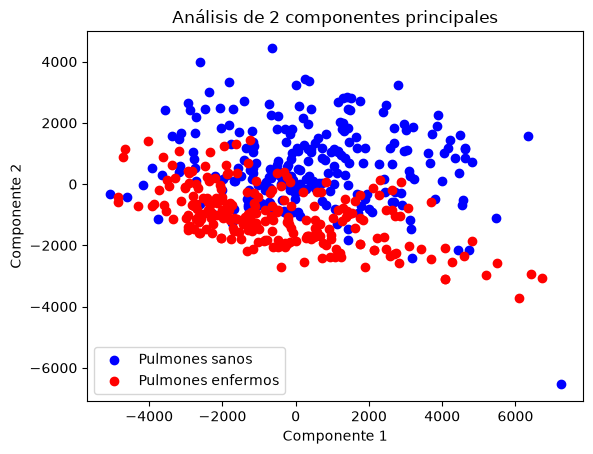

Mejor accuracy: 0.8504273504273504 con k = 12


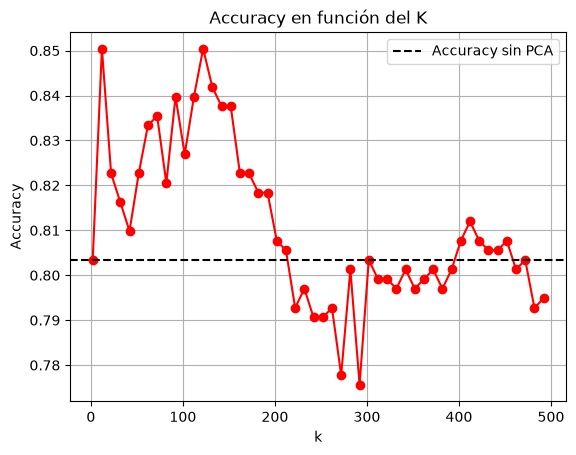

In [4]:
X_train, y_train = get_train_data()
X_test, y_test = get_test_data()

# 1.a)-------------SIN PCA-------------------------------------
# baseline del modelo sin reducción de dimensionalidad

lr_model = get_model()
train(X_train, y_train, lr_model)
accuracy_base = test(X_test, y_test, lr_model)
print(f"Accuracy antes de aplicar PCA: {accuracy_base}")


# 1.b)----------PROYECCIONES + SCATTER-------------------------
# proyecta los datos en 2 dimensiones para visualizar separación

U, S, V, ux = USV(X_train)  # Recibimos U, S, V, ux
X_test_K2 = proyectar_k(
    X_test, ux, V, 2
)  # Proyectamos el conjunto de test sobre la matriz de proyeccion
scatter1b(X_test_K2, y_test)


# 1.c)----------CON PCA + DISTINTOS K--------------
# compara accuracy para distintos niveles de reducción
valores_k = []
accuracies_por_k = []

for k in range(2, 500, 10):
    valores_k.append(k)
    lr_model_k = get_model()
    X_train_k = proyectar_k(X_train, ux, V, k)
    X_test_k = proyectar_k(X_test, ux, V, k)
    train(X_train_k, y_train, lr_model_k)
    accuracy_k = test(X_test_k, y_test, lr_model_k)
    accuracies_por_k.append(accuracy_k)

valores_k = np.array(valores_k)
accuracies_por_k = np.array(accuracies_por_k)

# mejor k según accuracy en test
idx_mejor = np.argmax(accuracies_por_k)
mejor_k = valores_k[idx_mejor]
mejor_accuracy = accuracies_por_k[idx_mejor]
print(f"Mejor accuracy: {mejor_accuracy} con k = {mejor_k}")

plt.plot(valores_k, accuracies_por_k, "ro-")
plt.title("Accuracy en función del K")
plt.axhline(accuracy_base, c="black", linestyle="--", label="Accuracy sin PCA")
plt.ylabel("Accuracy")
plt.xlabel("k")
plt.legend()
plt.grid()
plt.show()

### Reporte del Ejercicio 1

El accuracy obtenido al entrenar el clasificador sobre las imágenes completas es el *baseline*: representa el desempeño de referencia contra el cual se compara cualquier versión del 
modelo que se entrene sobre datos modificados con PCA. Este valor permite 
cuantificar, en los puntos siguientes, cuánto se pierde (o si eventualmente 
se gana) al proyectar los datos sobre un subespacio de menor dimensión.

La proyección del conjunto de test sobre las dos primeras componentes 
principales, junto con el scatter coloreado por clase (sano/neumonía), 
permite visualizar a simple vista si las direcciones de mayor varianza del 
conjunto de entrenamiento sirven para separar un pulmon enfermo de uno sano. Si los tipos de pulmon forman agrupamientos distinguibles en ese plano, es indicio de que gran parte de la información relevante para la clasificación está concentrada en esas primeras componentes. Si este no fuera el caso, la separación entre clases dependería también de direcciones de menor varianza, no de las principales obtenidas con $k=2$

Para estudiar cómo evoluciona el desempeño con la cantidad de componentes 
retenidas, se evalúa el accuracy del modelo PCA+LR para valores de $k$ que 
van desde una reducción muy agresiva ($k=2$) hasta una fracción considerable 
de la dimensión original, en pasos regulares, de forma de cubrir un rango 
amplio sin un costo computacional excesivo (entrenar y evaluar un modelo 
distinto para cada valor de $k$). El criterio de comparación es graficar el 
accuracy con el conjunto de testing en función de $k$ y graficar, como recta punteada 
horizontal, el accuracy del modelo base sin PCA.

La conclusión que se busca extraer de este análisis es de tipo cualitativo: 
identificar si existe un valor de $k$ a partir del cual el accuracy es igual o mejor que en baseline (lo que indicaría que las 
componentes principales adicionales aportan información nula o incluso llegan a confundir al modelo), o si, por el contrario, el desempeño sigue mejorando 
con $k$ creciente, lo que sugeriría que la información relevante 
está distribuida en muchas direcciones del espacio original.

## Ejercicio 2

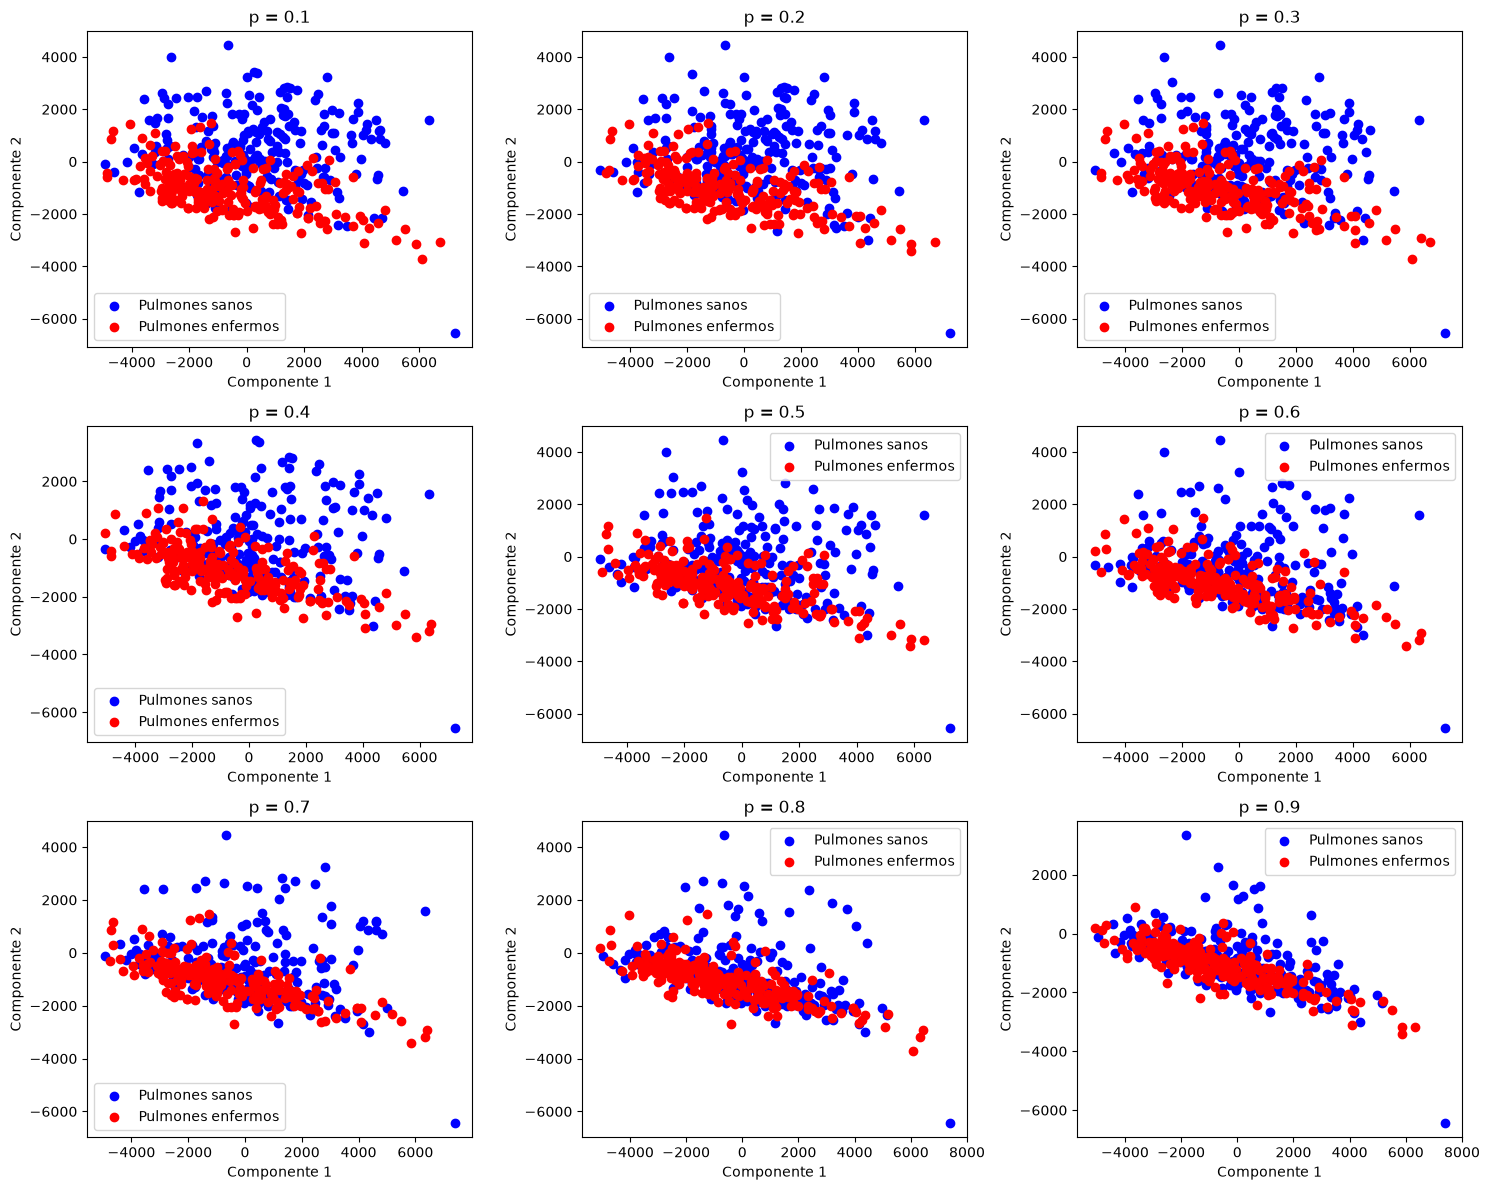

In [ ]:
"""
Reutilizo variables del punto 1
X_train, y_train, X_test, y_test
ux: Media
V: Matriz de componentes principales
"""

X_train_K2 = proyectar_k(X_train, ux, V, 2)
X_test_K2 = proyectar_k(X_test, ux, V, 2)

lr_model_MC = get_model()
train(X_train_K2, y_train, lr_model_MC)

A0 = test(X_test_K2, y_test, lr_model_MC)

# cada imagen puede rotarse con probabilidad p para evaluar robustez


def perturbaciones(X_test, p):
    X_test_perturbado = X_test.copy()
    for i in range(len(X_test_perturbado)):
        if np.random.rand() < p:
            img = X_test_perturbado[i].reshape(128, 128)
            img_rotada = np.rot90(img, 2)
            X_test_perturbado[i] = img_rotada.flatten()
    return X_test_perturbado


N_mc = 1000
tolerancia = 0.1

accuracies_promedio = []
prob_perdida_supera_tolerancia = []
accuracies_por_p = {}
probabilidades_MC = {}

p_values = np.arange(0.1, 1.0, 0.1)

# Para graficar -> que no salgan las imagenes separadas
def pausa():
    pass
ncols = 3
nrows = (len(p_values) + ncols-1) // ncols
fig = plt.figure(figsize=(15,12))
show_original = plt.show
plt.show = pausa

for idx,proba in enumerate(p_values):
    proba = round(proba, 1)
    accuracies_mc = []
    indicadores = []

    for i in range(N_mc):
        X_test_mod = perturbaciones(X_test, proba)
        X_test_K2_mod = proyectar_k(X_test_mod, ux, V, 2)

        accuracy_local = test(X_test_K2_mod, y_test, lr_model_MC)
        accuracies_mc.append(accuracy_local)

        perdida_i = A0 - accuracy_local
        indicador_i = 1 if perdida_i > tolerancia else 0
        indicadores.append(indicador_i)
        # solo un scatter por valor de p para visualizar la variación
        # a - Scatter solo una vez por cada proba distinta
        if i == 0:
            plt.subplot(nrows, ncols, idx + 1)
            scatter1b(X_test_K2_mod, y_test, titulo = f"p = {proba}")

    # promedio de la accuracy bajo perturbación
    # b - Metodo Montecarlo - Valor medio
    accuracies_mc = np.array(accuracies_mc)
    accuracy_promedio = np.mean(accuracies_mc)
    # probabilidad estimada de perder más que la tolerancia
    # c - Proba de superar tolerancia
    perdidas = A0 - accuracies_mc
    prob_perdida = np.mean(perdidas > tolerancia)

    accuracies_promedio.append(accuracy_promedio)
    prob_perdida_supera_tolerancia.append(prob_perdida)
    accuracies_por_p[proba] = accuracies_mc

    # 3 - promedio de las funciones indicadoras
    probabilidad_estimada = np.mean(indicadores)
    probabilidades_MC[proba] = probabilidad_estimada


# Grafico 2 a
plt.show = show_original
plt.tight_layout()
plt.show()

### 2a - Reporte del scatter por p

Para cada valor de la probabilidad de rotación p, se toma una única realización de la simulación: se perturba el conjunto de test rotando cada imagen 180 grados con probabilidad p, y se proyecta ese conjunto perturbado sobre las mismas dos primeras componentes principales obtenidas a partis del conjunto de entrenamiento sin perturbar. Cada scatter muestra la posicion de las imágenes de test en el plano para esa realización, diferenciando la clase sana con color azul de la clase enferma con color rojo.

Como la base de proyección se ajustó sobre imágenes en su orientación
original, las imágenes que resultan rotadas quedan representadas en una zona distinta del plano a la que ocupan normalmente, ya que su estructura ya no se corresponde con las direcciones de mayor varianza aprendidas del train. Por eso, al comparar los nueve scatters entre sí, lo que debe analizarse es cómo cambia la dispersión y la mezcla entre clases a medida que aumenta p. Con valores chicos la mayoría de los puntos mantiene la disperción vista en el punto 1b. Por otro lado, con valores grandes los puntos se desplazan hacia la región correspondiente a las imágenes de la clase enferma.

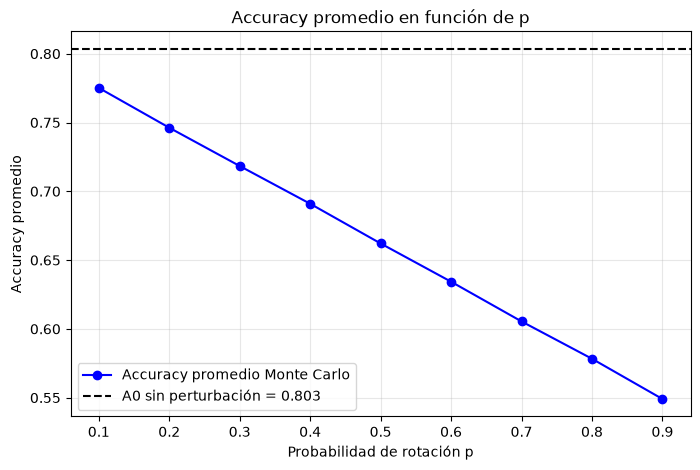

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(
    p_values,
    accuracies_promedio,
    "o-",
    color="blue",
    label="Accuracy promedio Monte Carlo",
)
plt.axhline(A0, linestyle="--", color="black", label=f"A0 sin perturbación = {A0:.3f}")
plt.xlabel("Probabilidad de rotación p")
plt.ylabel("Accuracy promedio")
plt.title("Accuracy promedio en función de p")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### 2b - Reporte del gráfico de accuracies promedio

El gráfico muestra el accuracy promedio del clasificador para cada
probabilidad de rotación $p$. La línea punteada representa el accuracy base
$A_0$, obtenido sin perturbaciones. Así, se observa cómo cambia el desempeño
del modelo al aumentar la probabilidad de rotar las imágenes de test.

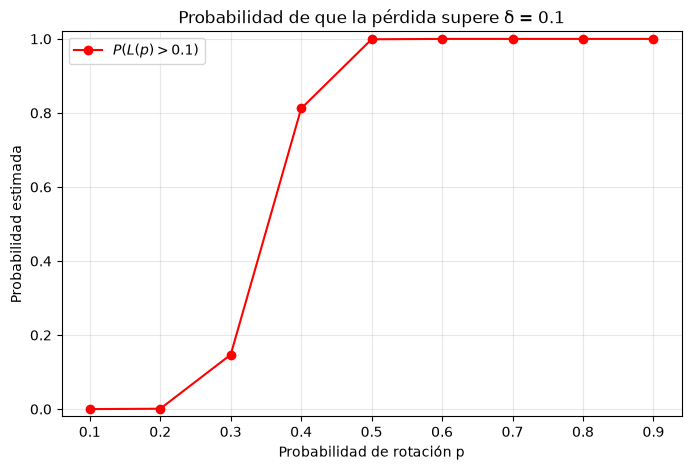

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(
    p_values,
    prob_perdida_supera_tolerancia,
    "o-",
    color="red",
    label=r"$P(L(p) > 0.1)$",
)
plt.xlabel("Probabilidad de rotación p")
plt.ylabel("Probabilidad estimada")
plt.title("Probabilidad de que la pérdida supere δ = 0.1")
plt.ylim(-0.02, 1.02)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### 2c -Reporte del gráfico de probabilidad de pérdida

El gráfico representa, para cada probabilidad de rotación $p$, la
probabilidad estimada de que la pérdida de accuracy supere la tolerancia
$\delta = 0.1$. Permite analizar cómo varía la frecuencia de pérdidas
significativas al aumentar la perturbación y evaluar la robustez del
clasificador ante imágenes rotadas.

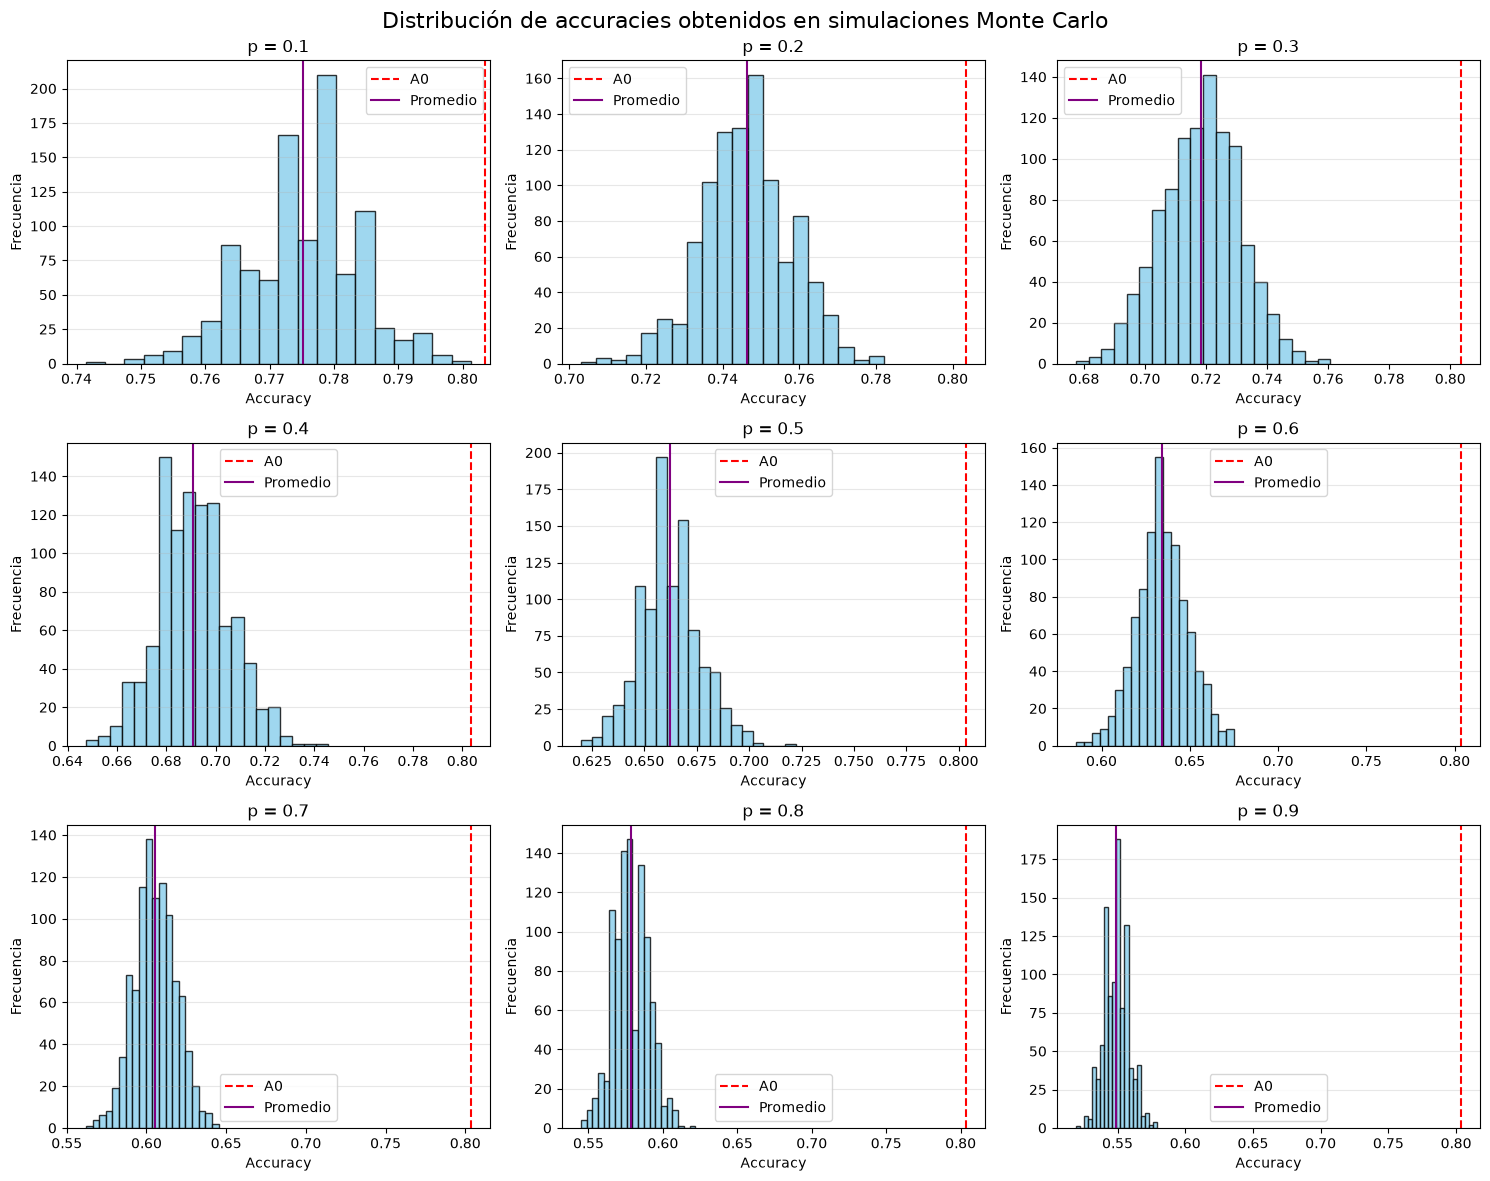

In [11]:
# 2(d) Histogramas de todos los valores de p en una misma figura

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

# cada histograma resume la distribución para un nivel distinto de perturbación
for ax, (proba, acc_mc) in zip(axes, accuracies_por_p.items()):
    ax.hist(acc_mc, bins=20, color="skyblue", edgecolor="black", alpha=0.8)

    ax.axvline(A0, color="red", linestyle="--", linewidth=1.5, label="A0")

    ax.axvline(
        np.mean(acc_mc), color="purple", linestyle="-", linewidth=1.5, label="Promedio"
    )

    ax.set_title(f"p = {proba}")
    ax.set_xlabel("Accuracy")
    ax.set_ylabel("Frecuencia")
    ax.grid(axis="y", alpha=0.3)
    ax.legend()

plt.suptitle(
    "Distribución de accuracies obtenidos en simulaciones Monte Carlo", fontsize=16
)

plt.tight_layout()
plt.show()

### 2d - Reporte de histogramas

Cada subplot muestra la distribución de los accuracies obtenidos en las $N_{MC}$ simulaciones para un valor fijo de $p$. La línea roja indica el accuracy base $A_0$ y la línea violeta el accuracy promedio de las simulaciones. La comparación permite analizar cómo cambian la posición, dispersión y distancia respecto de $A_0$ al variar la perturbación.

### Reporte final del ejercicio 2

A lo largo del ejercicio se estimaron, mediante simulación Monte Carlo con $N_{MC}$ realizaciones independientes por cada valor de p, tres cantidades relacionadas entre sí: el accuracy promedio $\mathbb{E}[A_p]$, la probabilidad de que la pérdida supere la tolerancia $\mathbb{P}_p(L(p) > \delta)$, y la distribución completa de los accuracies obtenidos en cada simulación.

El accuracy promedio resume el desempeño esperado del clasificador para cada nivel de perturbación, la probabilidad de superar la tolerancia muestra qué tan frecuentemente esa pérdida de desempeño resulta inaceptable según el criterio elegido ($\delta =
0.1$), y los histogramas permiten ver si esa degradación ocurre de forma progresiva entre simulaciones o si el accuracy se reparte en grupos claramente diferenciados según cuántas imágenes fueron rotadas en cada realización.

Para la conclusión, se debe identificar si existe un rango de $p$ en el que el modelo PCA+LR mantiene un desempeño aceptable (accuracy cercano a $A_0$ y probabilidad de pérdida baja), a partir de qué punto la perturbación empieza a degradar significativamente la clasificación, y si esa transición es progresiva o abrupta. Este comportamiento se asocia con los scatters del punto 2a: el valor de p donde las clases dejan de distinguirse visualmente en el plano de componentes principales debería coincidir con la zona donde la probabilidad de pérdida y la caída del accuracy aumentan.

## Ejercicio 3 — Justificación mediante la Ley de los Grandes Números

Para cada valor fijo de la probabilidad de perturbación $p$, realizamos
$N_{MC}$ simulaciones independientes. En la simulación $i$, se obtiene un
accuracy $A_p^{(i)}$ y, por lo tanto, una pérdida:

$$
L_i(p) = A_0 - A_p^{(i)}
$$

donde $A_0$ es el accuracy del clasificador sin perturbaciones y
$A_p^{(i)}$ es el accuracy obtenido en la realización $i$ al rotar cada
imagen de test con probabilidad $p$.

Definimos la variable aleatoria indicadora del evento de interés:


$$
I_i =
\begin{cases}
1, & \text{si } L_i(p) > \delta, \\
0, & \text{si } L_i(p) \leq \delta.
\end{cases}
$$

La esperanza de una variable indicadora es igual a la probabilidad del
evento que indica. Por lo tanto:

$$
\mathbb{E}[I_i]
=
\mathbb{E}\left[\mathbb{1}\{L_i(p) > \delta\}\right]
=
P_p\bigl(L(p) > \delta\bigr)
$$

Para un valor fijo de $p$, las simulaciones se generan de manera
independiente y con la misma distribución. En consecuencia,
$I_1, I_2, \ldots, I_{N_{MC}}$ son variables aleatorias independientes e
idénticamente distribuidas, cuyos valores posibles son $0$ y $1$.

Por la Ley de los Grandes Números, al aumentar el número de simulaciones,
el promedio muestral converge a la esperanza:

$$
\frac{1}{N_{MC}}
\sum_{i=1}^{N_{MC}} I_i
\xrightarrow[N_{MC} \to \infty]{}
\mathbb{E}[I_i]
$$

Reemplazando la definición de $I_i$, se obtiene el estimador de la
probabilidad solicitada:

$$
\widehat{P}_p\bigl(L(p) > \delta\bigr)
=
\frac{1}{N_{MC}}
\sum_{i=1}^{N_{MC}}
\mathbb{1}\{L_i(p) > \delta\}
$$

Por lo tanto, este promedio estima la proporción de simulaciones para las
cuales la pérdida de accuracy supera la tolerancia $\delta$. A medida que
$N_{MC}$ aumenta, el estimador se aproxima a la probabilidad verdadera
$P_p\bigl(L(p) > \delta\bigr)$.

En la implementación, la expresión `L_p > tolerancia` genera una
variable indicadora para cada simulación: vale `True` si la pérdida supera
el umbral y `False` en caso contrario. Al calcular
`np.mean(L_p > tolerancia)`, NumPy promedia estos valores, interpretando
`True` como 1 y `False` como 0. De este modo, el resultado representa la
proporción de simulaciones en las que ocurre el evento
$L_i(p) > \delta$, que es precisamente el estimador Monte Carlo
justificado anteriormente.

In [12]:
print("Estimación Monte Carlo de P(L(p) > δ)")
print(f"Tolerancia δ = {tolerancia}")
print(f"Cantidad de simulaciones N_mc = {N_mc}\n")

for proba, probabilidad_estimada in probabilidades_MC.items():
    print(
        f"p = {proba:.1f} | "
        f"P_hat(L(p) > {tolerancia}) = {probabilidad_estimada:.4f}"
    )

Estimación Monte Carlo de P(L(p) > δ)
Tolerancia δ = 0.1
Cantidad de simulaciones N_mc = 1000

p = 0.1 | P_hat(L(p) > 0.1) = 0.0000
p = 0.2 | P_hat(L(p) > 0.1) = 0.0010
p = 0.3 | P_hat(L(p) > 0.1) = 0.1470
p = 0.4 | P_hat(L(p) > 0.1) = 0.8120
p = 0.5 | P_hat(L(p) > 0.1) = 0.9990
p = 0.6 | P_hat(L(p) > 0.1) = 1.0000
p = 0.7 | P_hat(L(p) > 0.1) = 1.0000
p = 0.8 | P_hat(L(p) > 0.1) = 1.0000
p = 0.9 | P_hat(L(p) > 0.1) = 1.0000
